<h1 style="background-color:#F527BB; color:white;">Práctica 3: Implementación en producción </h1>

**Alumna:** Erika Margarita Villaobos Martínez

**Fecha de entrega:** 07 de junio 2026

___

<h2 style="background-color:#FFCCF5; color:#595959;">Paso 1: Librerias y lectura de archivos </h2> 

In [1]:
## Generales
import pandas as pd
import numpy as np
import json

## Exploración de datos
from skimpy import skim
import data_profiling
from data_profiling import ProfileReport
import plotly.express as px

## Limpieza variables de texto
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
import re
from nltk.corpus import stopwords
import nltk
from collections import Counter

## Guardar modelos
import pickle
import joblib

In [38]:
## Modelado no supervisado
import umap
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.utils import resample
from yellowbrick.cluster import SilhouetteVisualizer
from yellowbrick.cluster import KElbowVisualizer
from sklearn.decomposition import TruncatedSVD

In [3]:
## Modelado supervisado
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import xgboost as xgb
from sklearn.metrics import classification_report

<h2 style="color:#F527BB; font-size: 1.2em; font-weight: bold;"> Tweets </h2>

In [4]:
df = pd.read_csv("../data/practica_3/tweets-sentiment.csv", encoding="ansi")

In [5]:
df.head()

,tweet_date_created,tweet_id,tweet_text,language,sentiment,sentiment_score
0,2018-08-08T13:09:15.489000,1027179935184703489,"Alisson puede estar más tranquilo, no cargará ...",es,POSITIVE,"{""Neutral"":0.082259356975555419921875,""Negativ..."
1,2018-08-08T18:27:37.320000,1027260056092344320,@iPincheViky @ChelseaFC Es que el director eje...,es,NEUTRAL,"{""Neutral"":0.827011644840240478515625,""Negativ..."
2,2018-08-12T14:59:31.520000,1028657238116843520,Upto £100 #freebets &gt; https://t.co/cbjeMXI9...,es,NEUTRAL,"{""Neutral"":0.930982112884521484375,""Negative"":..."
3,2018-08-04T13:23:30.257000,1025733971320160257,"Bobby Duncan, primo de Steven Gerrard, deja la...",es,NEUTRAL,"{""Neutral"":0.906872212886810302734375,""Negativ..."
4,2018-07-28T11:21:06.480000,1023166450981396480,@TorreiraForeva @lepvtron @Arsenal @IntChampio...,es,NEUTRAL,"{""Neutral"":0.942405760288238525390625,""Negativ..."


In [6]:
%%time
df["sentiment_score"] = df["sentiment_score"].apply(json.loads)
sentiment_df = df["sentiment_score"].apply(pd.Series)

CPU times: total: 34.8 s
Wall time: 34.9 s


In [7]:
df = pd.concat([df.drop(columns=["sentiment_score"]), sentiment_df], axis=1)

In [8]:
df.head()

,tweet_date_created,tweet_id,tweet_text,language,sentiment,Neutral,Negative,Positive,Mixed
0,2018-08-08T13:09:15.489000,1027179935184703489,"Alisson puede estar más tranquilo, no cargará ...",es,POSITIVE,0.082259,0.036536,0.745924,0.135281
1,2018-08-08T18:27:37.320000,1027260056092344320,@iPincheViky @ChelseaFC Es que el director eje...,es,NEUTRAL,0.827012,0.078550,0.071943,0.022495
2,2018-08-12T14:59:31.520000,1028657238116843520,Upto £100 #freebets &gt; https://t.co/cbjeMXI9...,es,NEUTRAL,0.930982,0.031428,0.030184,0.007406
3,2018-08-04T13:23:30.257000,1025733971320160257,"Bobby Duncan, primo de Steven Gerrard, deja la...",es,NEUTRAL,0.906872,0.057496,0.024875,0.010757
4,2018-07-28T11:21:06.480000,1023166450981396480,@TorreiraForeva @lepvtron @Arsenal @IntChampio...,es,NEUTRAL,0.942406,0.031377,0.020383,0.005833


<h2 style="background-color:#FFCCF5; color:#595959;">Paso 2: EDA </h2> 

In [10]:
profile = ProfileReport(df.sample(frac=0.25).drop(columns=["tweet_id", "language"]), title="Profiling Report", plot={"wordcloud": {"enable": False}})

In [11]:
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                            | 0/8 [00:00<?, ?it/s]
%|██████████▌                                                                         | 1/8 [00:00<00:06,  1.13it/s]
100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:02<00:00,  3.51it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

<h2 style="background-color:#FFCCF5; color:#595959;">Paso 3: Pre-procesamiento </h2>

<h2 style="color:#F527BB; font-size: 1.2em; font-weight: bold;"> Limpieza </h2>

In [9]:
df = df.drop(columns=["language", "tweet_date_created", "tweet_id"])

<h2 style="color:#F527BB; font-size: 1.2em; font-weight: bold;"> Segmentación de variables </h2>

In [10]:
var_id = ["tweet_id"] # 1 variable

In [11]:
var_date = ["tweet_date_created"] # 1 variable

In [12]:
var_cat = ["sentiment"] # 1 variable

In [13]:
var_text = ["tweet_text"] # 1 variable

In [14]:
var_target_s = ["sentiment"] # 1 variable

In [15]:
var_num = list(set(df.columns) - set(var_date) - set(var_id) - set(var_text) - set(var_cat)) # 4 varaibles

<h2 style="color:#F527BB; font-size: 1.2em; font-weight: bold;"> Codificación </h2>

In [16]:
sentiment_mapping = {
    "NEUTRAL": 0,
    "POSITIVE": 1,
    "NEGATIVE": 2,
    "MIXED": 3
}

In [17]:
df["sentiment"] = df["sentiment"].map(sentiment_mapping)

In [18]:
df.head()

,tweet_text,sentiment,Neutral,Negative,Positive,Mixed
0,"Alisson puede estar más tranquilo, no cargará ...",1,0.082259,0.036536,0.745924,0.135281
1,@iPincheViky @ChelseaFC Es que el director eje...,0,0.827012,0.078550,0.071943,0.022495
2,Upto £100 #freebets &gt; https://t.co/cbjeMXI9...,0,0.930982,0.031428,0.030184,0.007406
3,"Bobby Duncan, primo de Steven Gerrard, deja la...",0,0.906872,0.057496,0.024875,0.010757
4,@TorreiraForeva @lepvtron @Arsenal @IntChampio...,0,0.942406,0.031377,0.020383,0.005833


<h2 style="color:#F527BB; font-size: 1.2em; font-weight: bold;"> Transformación variable de texto </h2>

In [19]:
# Carga modelo de spaCy en español
nlp = spacy.load("es_core_news_sm", disable=["ner", "parser"])

In [20]:
# Función de limpieza y normalización
def clean_text(text):
    # Quitar URLs, menciones y hashtags
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    
    # Pasar a minúsculas
    text = text.lower()
    
    # Quitar caracteres no alfabéticos
    text = re.sub(r"[^a-záéíóúñü\s]", "", text)
    
    return text

In [21]:
def lemmatize_pipe(texts):
    docs = nlp.pipe(texts, disable=["ner", "parser"])  # desactiva componentes que no necesitas
    return [" ".join([token.lemma_ for token in doc if not token.is_stop]) for doc in docs]

In [22]:
%%time
# Aplicar sobre la columna
df["tweet_clean"] = lemmatize_pipe(df["tweet_text"].apply(clean_text))

CPU times: total: 4min 42s
Wall time: 4min 44s


In [23]:
df

,tweet_text,sentiment,Neutral,Negative,Positive,Mixed,tweet_clean
0,"Alisson puede estar más tranquilo, no cargará ...",1,0.082259,0.036536,0.745924,0.135281,alisser tranquilo cargar peso arquero caro his...
1,@iPincheViky @ChelseaFC Es que el director eje...,0,0.827012,0.078550,0.071943,0.022495,director ejecutivo mujer so jajajajjaa
2,Upto £100 #freebets &gt; https://t.co/cbjeMXI9...,0,0.930982,0.031428,0.030184,0.007406,upto gt
3,"Bobby Duncan, primo de Steven Gerrard, deja la...",0,0.906872,0.057496,0.024875,0.010757,bobby duncar primo steven gerrard dejar canter...
4,@TorreiraForeva @lepvtron @Arsenal @IntChampio...,0,0.942406,0.031377,0.020383,0.005833,leon bailey or federico cheisa
...,...,...,...,...,...,...,...
132702,Apunta el diario Mirror que el #ManchesterUnit...,0,0.903017,0.068988,0.013636,0.014358,apuntar diario mirror estar pensar reuperar...
132703,@andresmarocco @sscnapoli @D_Ospina1 @Arsenal ...,0,0.731345,0.014611,0.211623,0.042421,pasar ospina poner competencia arco sele...
132704,Final del partido @Everton 1 vs @WestHamEspano...,0,0.957551,0.006273,0.033076,0.003100,partido vs jornada
132705,"Amistoso, champions o Liga; el city es la perr...",0,0.936212,0.032482,0.022699,0.008607,amistoso champions ligar city perra liverpool


In [24]:
spanish_stopwords = stopwords.words("spanish")

In [25]:
# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, stop_words=spanish_stopwords)
X_tfidf = vectorizer.fit_transform(df["tweet_clean"])

In [26]:
print("Shape TF-IDF:", X_tfidf.shape)

Shape TF-IDF: (132707, 5000)


<h2 style="background-color:#FFCCF5; color:#595959;">Paso 4: Modelado </h2>

<h2 style="color:#F527BB; font-size: 1.2em; font-weight: bold;"> Supervisado </h2>

<p>  </p>
<img src="../imgs/metricas_cllasificación_practica3M5.png" alt="En verde podemos ver que a Kmenas le fue bien en todas las métricas" width="900" style="display: block; margin: 0 auto;">

In [106]:
def supervised_models(X, y, test_size=0.2, random_state=42):
    results = []
    models = {}

    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # --- Regresión Logística ---
    logreg = LogisticRegression(max_iter=1000, random_state=random_state)
    logreg.fit(X_train, y_train)
    models["logreg"] = logreg

    # Predicciones
    y_pred_train_log = logreg.predict(X_train)
    y_pred_test_log = logreg.predict(X_test)

    # Métricas entrenamiento
    results.append({
        "Modelo": "LogisticRegression",
        "Dataset": "Train",
        "Accuracy": accuracy_score(y_train, y_pred_train_log),
        "Precision": precision_score(y_train, y_pred_train_log, average="weighted"),
        "Recall": recall_score(y_train, y_pred_train_log, average="weighted"),
        "F1": f1_score(y_train, y_pred_train_log, average="weighted")
    })

    # Métricas validación
    results.append({
        "Modelo": "LogisticRegression",
        "Dataset": "Validation",
        "Accuracy": accuracy_score(y_test, y_pred_test_log),
        "Precision": precision_score(y_test, y_pred_test_log, average="weighted"),
        "Recall": recall_score(y_test, y_pred_test_log, average="weighted"),
        "F1": f1_score(y_test, y_pred_test_log, average="weighted")
    })

    # --- XGBoost ---
    xgb_clf = xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=random_state,
        use_label_encoder=False,
        eval_metric="mlogloss"
    )
    xgb_clf.fit(X_train, y_train)

    # Predicciones
    y_pred_train_xgb = xgb_clf.predict(X_train)
    y_pred_test_xgb = xgb_clf.predict(X_test)

    # Métricas entrenamiento
    results.append({
        "Modelo": "XGBoost",
        "Dataset": "Train",
        "Accuracy": accuracy_score(y_train, y_pred_train_xgb),
        "Precision": precision_score(y_train, y_pred_train_xgb, average="weighted"),
        "Recall": recall_score(y_train, y_pred_train_xgb, average="weighted"),
        "F1": f1_score(y_train, y_pred_train_xgb, average="weighted")
    })

    # Métricas validación
    results.append({
        "Modelo": "XGBoost",
        "Dataset": "Validation",
        "Accuracy": accuracy_score(y_test, y_pred_test_xgb),
        "Precision": precision_score(y_test, y_pred_test_xgb, average="weighted"),
        "Recall": recall_score(y_test, y_pred_test_xgb, average="weighted"),
        "F1": f1_score(y_test, y_pred_test_xgb, average="weighted")
    })

    return pd.DataFrame(results), models

In [107]:
%%time
results_df, models = supervised_models(X_tfidf, df["sentiment"])
logreg = models["logreg"]

C:\Users\erika\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\erika\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning:

[18:15:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.




CPU times: total: 10min 59s
Wall time: 1min 52s


In [108]:
results_df

,Modelo,Dataset,Accuracy,Precision,Recall,F1
0,LogisticRegression,Train,0.877832,0.860822,0.877832,0.855957
1,LogisticRegression,Validation,0.868247,0.844519,0.868247,0.844416
2,XGBoost,Train,0.871012,0.868591,0.871012,0.836761
3,XGBoost,Validation,0.861126,0.839408,0.861126,0.823368


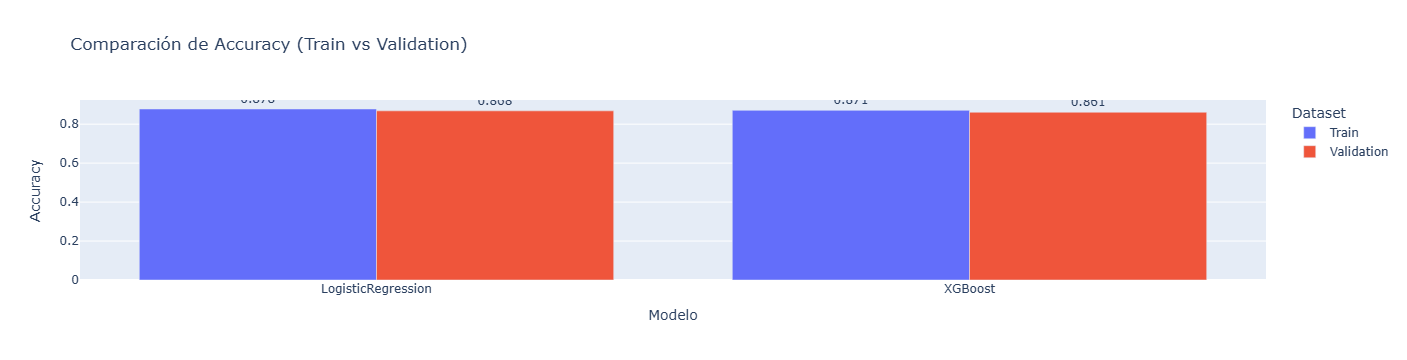

In [109]:
# Gráfico comparativo de Accuracy
fig_acc = px.bar(
    results_df,
    x="Modelo",
    y="Accuracy",
    color="Dataset",
    barmode="group",
    text=results_df["Accuracy"].round(3),
    title="Comparación de Accuracy (Train vs Validation)"
)
fig_acc.update_traces(textposition="outside")
fig_acc.show()

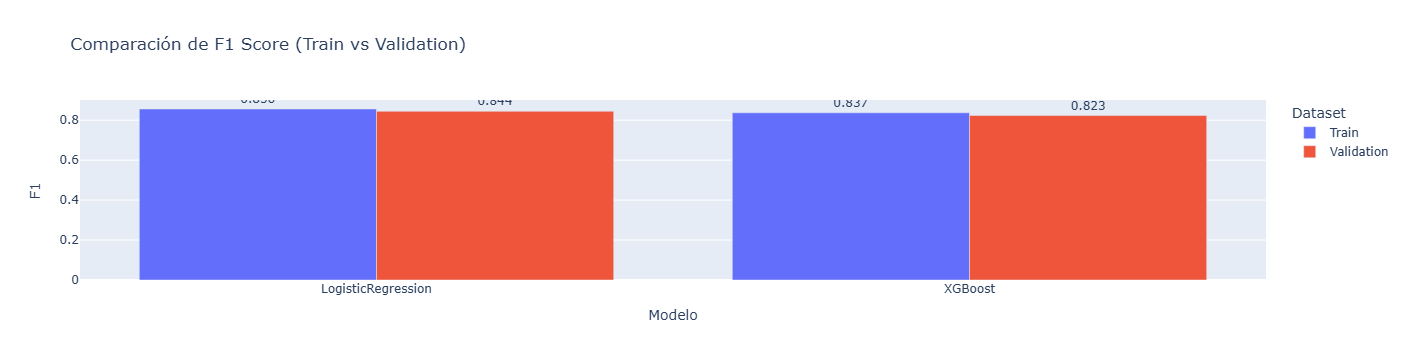

In [110]:
# Gráfico comparativo de F1
fig_f1 = px.bar(
    results_df,
    x="Modelo",
    y="F1",
    color="Dataset",
    barmode="group",
    text=results_df["F1"].round(3),
    title="Comparación de F1 Score (Train vs Validation)"
)
fig_f1.update_traces(textposition="outside")
fig_f1.show()

<h2 style="color:#F527BB; font-size: 1.2em; font-weight: bold;"> No supervisado </h2>

<h3 style="color:#F527BB; font-size: 1.2em; font-weight: bold;"> KMeans | GMM | DBSCAN - 6 Componentes </h3>

<p>  </p>
<img src="../imgs/metricas_clustering_practica3M5.png" alt="En verde podemos ver que a Kmenas le fue bien en todas las métricas" width="900" style="display: block; margin: 0 auto;">

In [27]:
df_sample = df.sample(n=5000, random_state=42)

In [28]:
X_sample = vectorizer.transform(df_sample["tweet_clean"])

In [29]:
%%time
# Diccionario para guardar resultados
results = []

# Iterar sobre distintas dimensionalidades de UMAP
for n in [15, 20, 30]:
    # Reducción con UMAP
    umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=n, random_state=42)
    embedding = umap_model.fit_transform(X_sample)
    
    # --- KMeans ---
    kmeans = KMeans(n_clusters=5, random_state=42)
    labels_kmeans = kmeans.fit_predict(embedding)
    results.append({
        "n_components": n,
        "method": "KMeans",
        "Silhouette": silhouette_score(embedding, labels_kmeans),
        "Davies-Bouldin": davies_bouldin_score(embedding, labels_kmeans),
        "Calinski-Harabasz": calinski_harabasz_score(embedding, labels_kmeans)
    })
    
    # --- DBSCAN ---
    dbscan = DBSCAN(eps=0.5, min_samples=10)
    labels_dbscan = dbscan.fit_predict(embedding)
    if len(set(labels_dbscan)) > 1:  # evitar error si todo queda en un cluster
        results.append({
            "n_components": n,
            "method": "DBSCAN",
            "Silhouette": silhouette_score(embedding, labels_dbscan),
            "Davies-Bouldin": davies_bouldin_score(embedding, labels_dbscan),
            "Calinski-Harabasz": calinski_harabasz_score(embedding, labels_dbscan)
        })
    
    # --- GMM ---
    gmm = GaussianMixture(n_components=5, random_state=42)
    labels_gmm = gmm.fit_predict(embedding)
    results.append({
        "n_components": n,
        "method": "GMM",
        "Silhouette": silhouette_score(embedding, labels_gmm),
        "Davies-Bouldin": davies_bouldin_score(embedding, labels_gmm),
        "Calinski-Harabasz": calinski_harabasz_score(embedding, labels_gmm)
    })

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)
print(results_df)

C:\Users\erika\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\erika\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\erika\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   n_components  method  Silhouette  Davies-Bouldin  Calinski-Harabasz
0            15  KMeans    0.281272        0.900649        2940.101807
1            15  DBSCAN   -0.067237        1.591841         929.025452
2            15     GMM    0.279598        0.908081        2925.142334
3            20  KMeans    0.217075        0.930102        3531.995605
4            20  DBSCAN   -0.018559        1.094785        1004.550232
5            20     GMM    0.227062        1.428026        3306.800781
6            30  KMeans    0.208571        1.398404        2133.533936
7            30  DBSCAN   -0.051511        1.063387         951.712769
8            30     GMM    0.209705        1.676503        2137.613525
CPU times: total: 4min 11s
Wall time: 4min 5s


<h2 style="color:#F527BB; font-size: 1.2em; font-weight: bold;"> Silueta KMeans - 10 Clusters </h2>

N Clusters : 2
Score Silueta : 0.8999999761581421


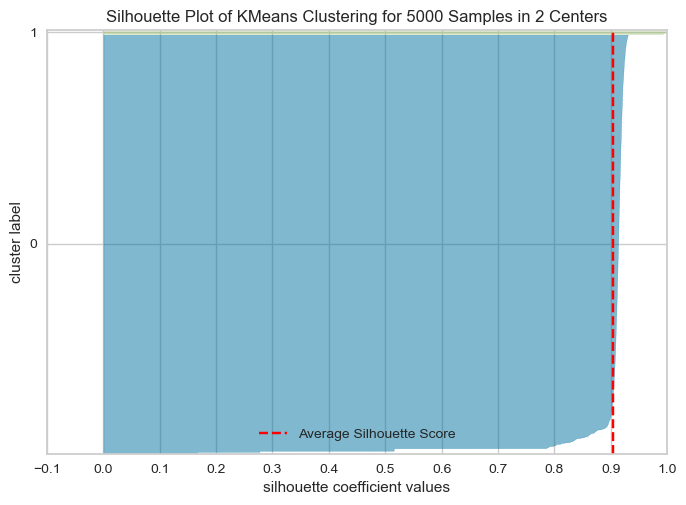

N Clusters : 3
Score Silueta : 0.8999999761581421


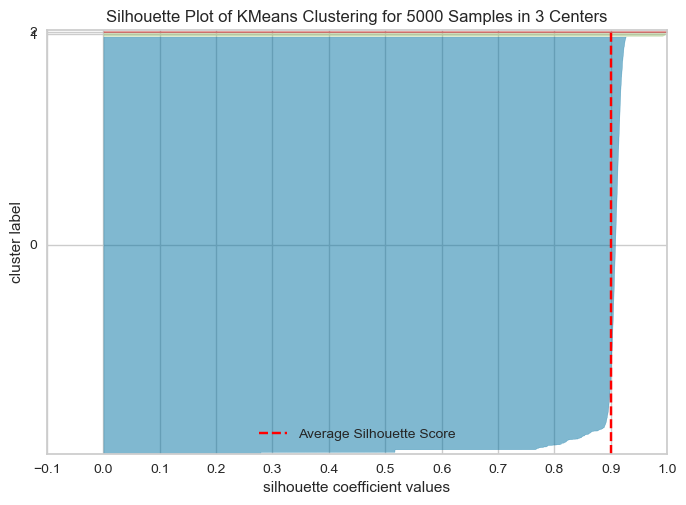

N Clusters : 4
Score Silueta : 0.8600000143051147


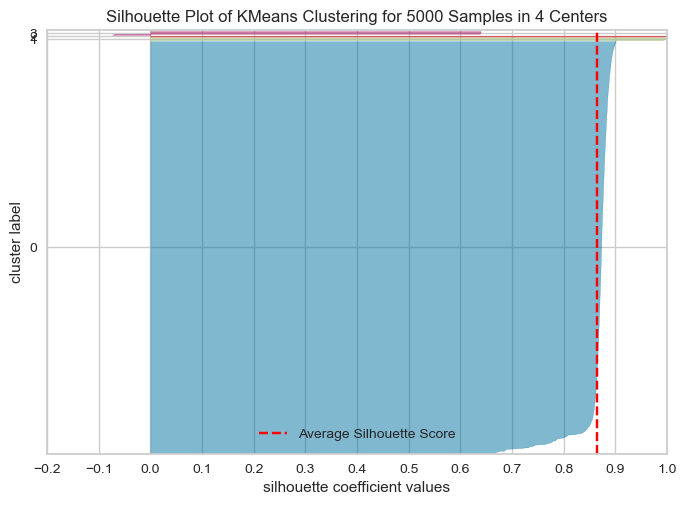

N Clusters : 5
Score Silueta : 0.25


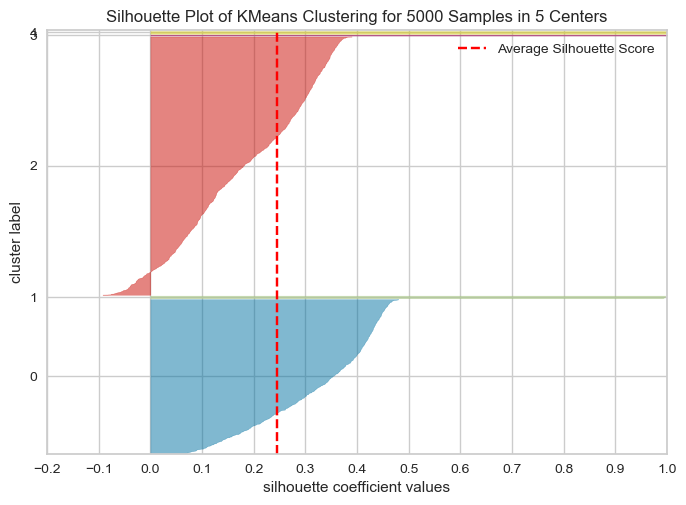

CPU times: total: 14.3 s
Wall time: 9.22 s


In [30]:
%%time
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embedding)

    # Crear muestra para métricas
    X_sample, labels_sample = resample(
        embedding, labels,
        n_samples=5000, random_state=42
    )

    # Visualización de silueta
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick')
    visualizer.fit(X_sample, labels_sample)
    print(f"N Clusters : {k}")
    print(f"Score Silueta : {round(silhouette_score(X_sample, labels_sample), 2)}")
    visualizer.show()

<h2 style="color:#F527BB; font-size: 1.2em; font-weight: bold;"> Codo KMeans - 30 Componentes </h2>

C:\Users\erika\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


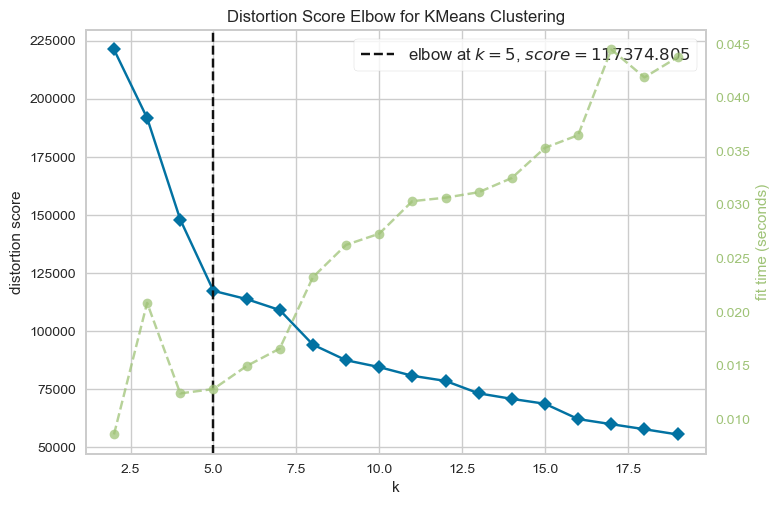

CPU times: total: 40.1 s
Wall time: 37.7 s


<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [31]:
%%time
# Reducción con UMAP a 30 componentes sobre TF-IDF
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=30, random_state=42)
embedding_cluster = umap_model.fit_transform(X_sample)

# Función para graficar el codo
def codo(X, min_compo, max_compo):
    model = KMeans(random_state=42)
    visualizer = KElbowVisualizer(model, k=(min_compo, max_compo))
    visualizer.fit(X)
    return visualizer.show()

# Ejecución del codo
codo(embedding_cluster, 2, 20)

<h2 style="color:#F527BB; font-size: 1.2em; font-weight: bold;"> KMeans - Visualización de clusters a 3 componentes </h2>

In [32]:
%%time
# Reducción de dimensiones a 3 componentes
umap_vis3d = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=42)
embedding_3d = umap_vis3d.fit_transform(X_sample)

# KMeans con 4 clusters
KM_3 = KMeans(n_clusters=3, n_init=100, init='k-means++', random_state=42).fit(embedding_3d)
labels = KM_3.labels_

# Crear DataFrame con etiquetas
datos_vis = pd.DataFrame({
    "comp1": embedding_3d[:,0],
    "comp2": embedding_3d[:,1],
    "comp3": embedding_3d[:,2],
    "cluster": labels
})

C:\Users\erika\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CPU times: total: 13.9 s
Wall time: 10.7 s


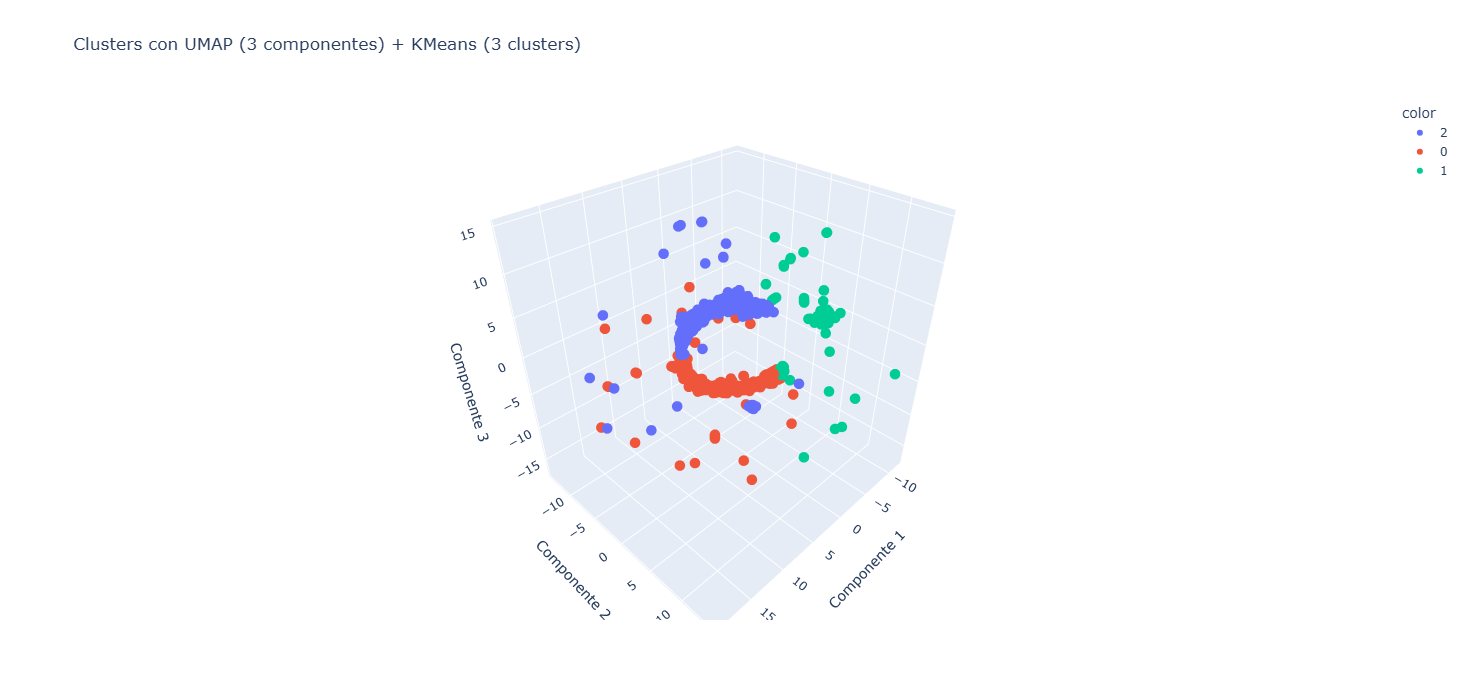

In [33]:
# Gráfico 3D
fig = px.scatter_3d(
    datos_vis, x="comp1", y="comp2", z="comp3",
    color=datos_vis["cluster"].astype(str),
    labels={"comp1": "Componente 1", "comp2": "Componente 2", "comp3": "Componente 3"},
    title="Clusters con UMAP (3 componentes) + KMeans (3 clusters)"
)

# Personalización de puntos
fig.update_traces(
    marker=dict(size=6, line=dict(width=0, color="Black")),
    selector=dict(mode="markers")
)

# Tamaño gráfico
fig.update_layout(
    width=900,   # ancho
    height=700   # alto
)


fig.show()

In [34]:
# Conteo de tweets por cluster
cluster_counts = datos_vis["cluster"].value_counts()

# Proporciones en porcentaje
cluster_percentages = cluster_counts / len(datos_vis) * 100

# Mostrar resultados
print("Distribución de clusters:")
print(cluster_percentages.round(2).astype(str) + "%")

Distribución de clusters:
cluster
2    43.36%
0    41.84%
1     14.8%
Name: count, dtype: object


In [35]:
fig_pie = px.pie(
    cluster_counts,
    values=cluster_counts.values,
    names=cluster_counts.index.astype(str),
    title="Proporción de tweets por cluster"
)
fig_pie.show()

In [46]:
%%time
# Reducción con TruncatedSVD (ejemplo: 15 componentes)
svd_model = TruncatedSVD(n_components=15, random_state=42)
X_reduced = svd_model.fit_transform(X_tfidf)

CPU times: total: 2.66 s
Wall time: 2.36 s


In [47]:
# KMeans sobre espacio reducido
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_reduced)

KMeans(n_clusters=3, random_state=42)

<h2 style="background-color:#FFCCF5; color:#595959;">Paso 5: Perfilamiento </h2>

**Cluster 0 - Aficionados:** Suelen tener opiniones neutrales y mixtas, lo que significa que son aficionados que dan seguimiento a los partidos
<br>
**Cluster 1 - Fifas:** Suelen tener opiniones negativas, lo que indica que no son constantes ni fanáticos de algún equipo
<br>
**Cluster 2 - Fanáticos:** Suelen tener opiniones positivas, por lo que se deduce que son fieles a un equipo favorito

In [67]:
df_sample = df_sample.copy()
df_sample["cluster"] = labels

In [69]:
perfil_num = (
    df_sample.groupby("cluster")[var_num]
      .mean()
      .style.background_gradient(cmap="Blues")
)
perfil_num

,Neutral,Positive,Negative,Mixed
cluster,,,,
0,0.711471,0.138256,0.113683,0.036590
1,0.704882,0.136904,0.122029,0.036184
2,0.706904,0.139960,0.116957,0.036179


In [70]:
def perfil_categorica(df, col):
    return (
        df_sample.groupby("cluster")[col]
          .value_counts(normalize=True)  # proporción por categoría
          .unstack(fill_value=0)
          .style.background_gradient(cmap="Blues")
    )

perfil_categorica(df_sample, "sentiment")

sentiment,0,1,2,3
cluster,,,,
0,0.845602,0.074570,0.073136,0.006692
1,0.837838,0.071622,0.083784,0.006757
2,0.828413,0.083026,0.083487,0.005074


In [74]:
for c in df_sample["cluster"].unique():
    textos = df_sample.loc[df_sample["cluster"]==c, "tweet_clean"]
    palabras = " ".join(textos).split()
    top = Counter(palabras).most_common(10)
    print(f"Cluster {c} → {top}")

Cluster 2 → [('equipo', 164), ('partido', 161), ('gol', 160), ('jugador', 148), ('jugar', 126), ('él', 122), ('ganar', 117), ('temporada', 114), ('vs', 107), ('año', 105)]
Cluster 0 → [('equipo', 201), ('partido', 187), ('jugador', 147), ('gol', 136), ('jugar', 132), ('vs', 131), ('él', 129), ('temporada', 115), ('ganar', 99), ('año', 85)]
Cluster 1 → [('equipo', 68), ('partido', 67), ('jugador', 51), ('jugar', 49), ('gol', 46), ('vs', 40), ('llegar', 40), ('ganar', 39), ('año', 39), ('él', 36)]


<h2 style="background-color:#FFCCF5; color:#595959;">Paso 6: Guardado de modelos y vectorización </h2>

In [92]:
# Guardar el vectorizador TF-IDF
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']

In [113]:
# Guardar el modelo supervisado ganador (Regresión Logística)
with open("../models/regression_model.pkl", "wb") as f:
    pickle.dump(logreg, f)

In [48]:
# Guardar reducción de dimensiones SVD
joblib.dump(svd_model, "../models/svd_model.pkl")

['../models/svd_model.pkl']

In [49]:
# Guardar el modelo no supervisado ganador (KMeans)
joblib.dump(kmeans, "../models/kmeans_model.pkl")

['../models/kmeans_model.pkl']

<h2 style="background-color:#FFCCF5; color:#595959;">Paso 7: Llamado Curl local </h2>

In [43]:
import requests

In [44]:
url = "http://127.0.0.1:8000/predict"
payload = {"tweet_text":"El @ManCity sufre su primer empate"}

In [51]:
response = requests.post(url, json=payload)
print(response.json())

{'status': 'success', 'data': {'timestamp': '03/06/2026T22:09:07', 'student_name': 'Erika Margarita Villalobos Martinez', 'proba_positive': 0.04038769198247566, 'proba_negative': 0.023891285766996534, 'proba_neutral': 0.9335690790799483, 'proba_mixed': 0.0021519431705794394, 'class': 'NEUTRAL', 'cluster': 'Aficionados'}}


In [10]:
from fastapi import FastAPI
from pydantic import BaseModel
from predictor import Predictor

ModuleNotFoundError: No module named 'predictor'

In [ ]:
app = FastAPI()
predictor = Predictor(model_dir="models")

In [ ]:
class TweetInput(BaseModel):
    tweet_text: str

@app.post("/predict")
def predict_tweet(input_data: TweetInput):
    result = predictor.predict(input_data.tweet_text)
    return result

In [8]:
url = "https://mi-servicio-uc.a.run.app/predict"
payload = {"tweet_text": "Ejemplo de tweet"}

In [9]:
response = requests.post(url, json=payload)
print(response.json())

JSONDecodeError: Expecting value: line 2 column 1 (char 1)